In [307]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [308]:
from pathlib import Path
import argparse
import logging

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import ConcatDataset, DataLoader

from tokamak_foundation_model.data.data_loader import TokamakH5Dataset, collate_fn
from tokamak_foundation_model.trainer.trainer import UnimodalTrainer

from tokamak_foundation_model.models.modality import (
    SlowTimeSeriesAutoEncoder,
    FastTimeSeriesAutoEncoder,
    SpatialProfileAutoEncoder,
    SpectrogramAutoEncoder,
    VideoAutoEncoder,
)

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

In [309]:
MODEL_REGISTRY = {
    "fast_time_series": FastTimeSeriesAutoEncoder,
    "slow_time_series": SlowTimeSeriesAutoEncoder,
    "profile": SpatialProfileAutoEncoder,
    "spectrogram": SpectrogramAutoEncoder,
    "video": VideoAutoEncoder,
}

In [310]:
signal_name = 'ece'
model_name = 'spectrogram'

d_model = 16
n_tokens = None

working_dir = '/scratch/gpfs/nc1514/FusionAIHub/runs'
stats_path = '../../data/preprocessing_stats.pt'

In [311]:
working_dir = Path(working_dir)
stats_path = Path(stats_path)

checkpoint_path = working_dir / f"{signal_name}_{model_name}" / "checkpoint.pth"
data_dir = Path('/scratch/gpfs/EKOLEMEN/big_d3d_data/dummy_foundation_model_data')

In [312]:
stats = torch.load(stats_path)

hdf5_files = sorted(data_dir.glob("*.h5"))
datasets_processed = [
    TokamakH5Dataset(
        hdf5_path=str(f),
        preprocessing_stats=stats,
        input_signals=[signal_name],
        target_signals=[signal_name],
        prediction_mode=False,
    )
    for f in hdf5_files
]

concatenated_dataset = ConcatDataset(datasets_processed)

sample_data = next(iter(concatenated_dataset))[signal_name]

In [313]:
n_channels = sample_data.shape[0]

In [314]:
def build_model(model_name, n_channels, d_model, n_tokens):
    """Build the appropriate autoencoder.

    All autoencoders share the same interface: (n_channels, d_model, n_tokens).
    """
    cls = MODEL_REGISTRY[model_name]
    kwargs = dict(n_channels=n_channels, d_model=d_model)
    if n_tokens is not None:
        kwargs["n_tokens"] = n_tokens
    return cls(**kwargs)
    
model = build_model(model_name, n_channels, d_model, n_tokens).to(device)

SpectrogramAutoEncoder: n_channels=48, d_model=16, params=665,745


In [315]:
data = concatenated_dataset[5][signal_name]

In [316]:
model.load_state_dict(torch.load(checkpoint_path, weights_only=True))
model.eval()
print("Model loaded")

Model loaded


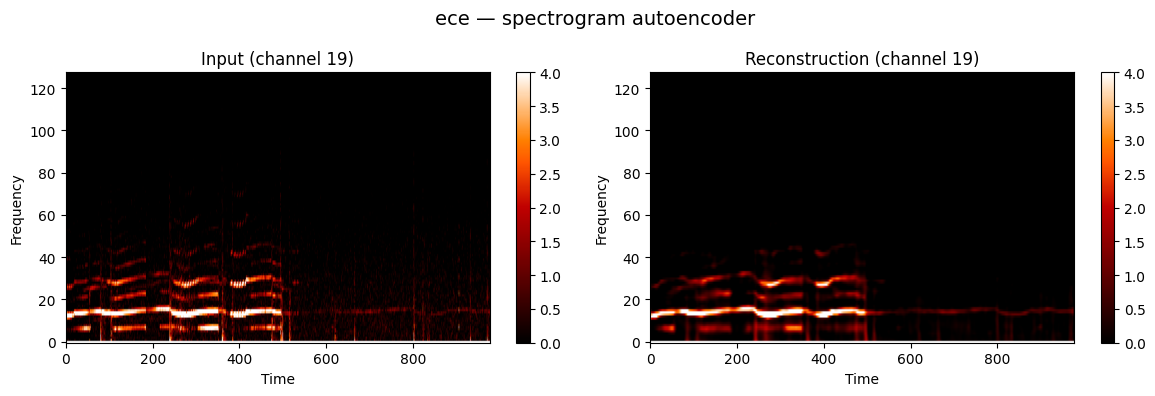

In [317]:
channel = 19

# Get a sample and run through model
x = data.unsqueeze(0).to(device)  # (1, C, F, T)
with torch.inference_mode():
    x_hat = model(x)

# Move to CPU for plotting
x_np = x[0, channel].cpu().numpy()        # (F, T)
x_hat_np = x_hat[0, channel].cpu().numpy()  # (F, T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(x_np, aspect='auto', origin='lower', cmap='gist_heat', vmin=0, vmax=4)
axes[0].set_title(f'Input (channel {channel})')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Frequency')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(x_hat_np, aspect='auto', origin='lower', cmap='gist_heat', vmin=0, vmax=4)
axes[1].set_title(f'Reconstruction (channel {channel})')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Frequency')
fig.colorbar(im1, ax=axes[1])

fig.suptitle(f'{signal_name} — {model_name} autoencoder', fontsize=14)
plt.tight_layout()
plt.show()

In [318]:
x.shape

torch.Size([1, 48, 128, 977])

In [319]:
with torch.inference_mode():
    z = model.encoder(x)

print(z.shape)

torch.Size([16, 12, 16, 123])


In [320]:
print(z.flatten().shape[0] / x.flatten().shape[0])

0.06294779938587512


In [321]:
import numpy as np

In [322]:
z.flatten().shape[0]

377856

In [305]:
np.sqrt(z.flatten().shape[0])

np.float64(614.6999267935535)